In [1]:
import sys

sys.path.append("..")
import json

import polars as pl

from src.preprocess import extract_relation, reverse_geocode_df, run_cluster, to_csv

/Users/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
entity_df = (
    pl.read_csv("../dataset/csv/entities.csv")
    .unique(subset=["wikimedia_url"])
    .with_columns(
        pl.col("poi_name_tags")
        .str.split(",")
        .list.eval(pl.element().filter(pl.element() != ""))
    )
    .with_columns(
        pl.col("nearby_pov_cluster")
        .str.split(",")
        .list.eval(pl.element().filter(pl.element() != ""))
        .list.eval(pl.element().cast(pl.Int64))
    )
)

In [3]:
entity_df.filter(pl.col("city") == "Tokyo").filter(pl.col("poi_name").str.contains("Tokyo Tower"))

entity_id,wikimedia_url,poi_name,wikidata_id,instance_tag,category,poi_name_tags,geohack_url,latitude,longitude,country_code,country,region,subregion,city,osm_id,nearby_pov_cluster
i64,str,str,str,str,str,list[str],str,f64,f64,str,str,str,str,str,str,list[i64]
3023,"""https://commons.wikimedia.org/…","""Tokyo Tower""","""Q110308312""","""[""observation tower"", ""transmi…","""tower""","[""東京タワー"", ""tokyo tower"", … ""東京鐵塔""]","""https://geohack.toolforge.org/…",35.658611,139.745556,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",null,[11]


In [4]:
from src.preprocess.utils import plot_pov_poi_hull

tower_spots = pl.read_csv("../dataset/csv/spots/tower_spots.csv").filter(pl.col("cluster_id") == 11)

plot_pov_poi_hull(tower_spots, entity_df.filter(pl.col("poi_name").str.contains("Tokyo Tower")))

/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower/tower-35.657328-139.749589-1762070306-38743501@N08-55296492242-n.jpg
/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower/tower-35.657328-139.749589-1762069996-38743501@N08-55297816150-n.jpg
/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower/tower-35.657328-139.749589-1762070428-38743501@N08-55297641819-n.jpg
/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower/tower-35.654011-139.745025-1701069367-83126816@N00-55226921149-n.jpg
/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower/tower-35.658616-139.745407-1764410776-66383090@N02-55034591055-n.jpg


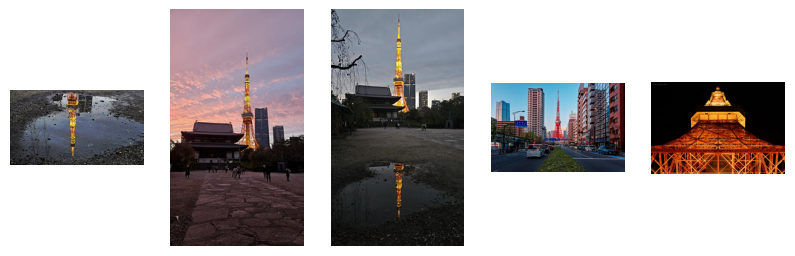

In [31]:
from PIL import Image
import os
import matplotlib.pyplot as plt

basepath = "/Users/affahrizain/projects/multi-pov-ir/dataset/images/tower"

towers = tower_spots.filter(pl.col("scene_pred") == "outdoor").to_dicts()
fig, ax = plt.subplots(1, 5, figsize=(10, 8))
for ii, i in zip(range(5), range(0, 5)):
    item = towers[i]
    path = os.path.join(basepath, item["img_id"])
    print(path)
    ax[ii].imshow(Image.open(path))
    ax[ii].axis("off")

In [20]:
tower_spots.filter(pl.col("scene_pred") == "indoor")

row_idx,category,id,owner,title,datetaken,tags,latitude,longitude,place_id,img_id,country_code,country,region,subregion,city,cluster_id,text,entities,scene_pred,viewpoint_pred
i64,str,i64,str,str,i64,str,f64,f64,str,str,str,str,str,str,str,i64,str,str,str,str
1454,"""tower""",55035061047,"""203463342@N02""","""Tokyo Tower 🗼""",1765510749,"""tokyo tower japan""",35.659324,139.745194,null,"""tower-35.659324-139.745194-176…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower 🗼 tokyo tower japa…","""tokyo tower,tokyo tower""","""indoor""","""aerial"""
1638,"""tower""",53874965308,"""201100961@N07""","""Tokyo Tower""",1678079481,"""japan japanese tokyo tower arc…",35.658863,139.745313,null,"""tower-35.658863-139.745313-167…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower japan japanese tok…","""tokyo tower,tokyo tower""","""indoor""","""ground"""
1725,"""tower""",53081388259,"""31029865@N06""","""Tokyo Tower""",1672624857,"""日 港区 田町 東京タワー tokyotower タワー t…",35.658547,139.745758,null,"""tower-35.658547-139.745758-167…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower 日 港区 田町 東京タワー toky…","""tokyo tower,東京タワー""","""indoor""","""ground"""
1730,"""tower""",53081687783,"""31029865@N06""","""Tokyo Tower""",1672624039,"""日 港区 田町 東京タワー tokyotower タワー t…",35.658022,139.744505,null,"""tower-35.658022-139.744505-167…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower 日 港区 田町 東京タワー toky…","""tokyo tower,東京タワー""","""indoor""","""aerial"""
1731,"""tower""",53081596360,"""31029865@N06""","""Tokyo Tower""",1672624402,"""日 港区 田町 東京タワー tokyotower タワー t…",35.658591,139.746919,null,"""tower-35.658591-139.746919-167…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower 日 港区 田町 東京タワー toky…","""tokyo tower,東京タワー""","""indoor""","""aerial"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
10344,"""tower""",443502512,"""27917561@N00""","""Tokyo Tower (2009)""",1258138268,"""park city november tower japan…",35.658708,139.744591,"""2V7yjYRTWr9WYOz3pA""","""tower-35.658708-139.744591-125…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Tokyo Tower (2009) park city n…","""tokyo tower,東京タワー""","""indoor""","""ground"""
10349,"""tower""",426167494,"""37843077@N00""","""Already Closed""",1174136982,"""tower japan geotagged mono tok…",35.658632,139.745411,"""340DfahQV7q87Z09KQ""","""tower-35.658632-139.745411-117…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Already Closed tower japan geo…","""tokyotower""","""indoor""","""ground"""
10361,"""tower""",332910534,"""37876875@N00""","""Romantic Tokyo""",1161766575,"""tower japan night geotagged to…",35.658517,139.745439,"""340DfahQV7q87Z09KQ""","""tower-35.658517-139.745439-116…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",11,"""Romantic Tokyo tower japan nig…","""""","""indoor""","""ground"""


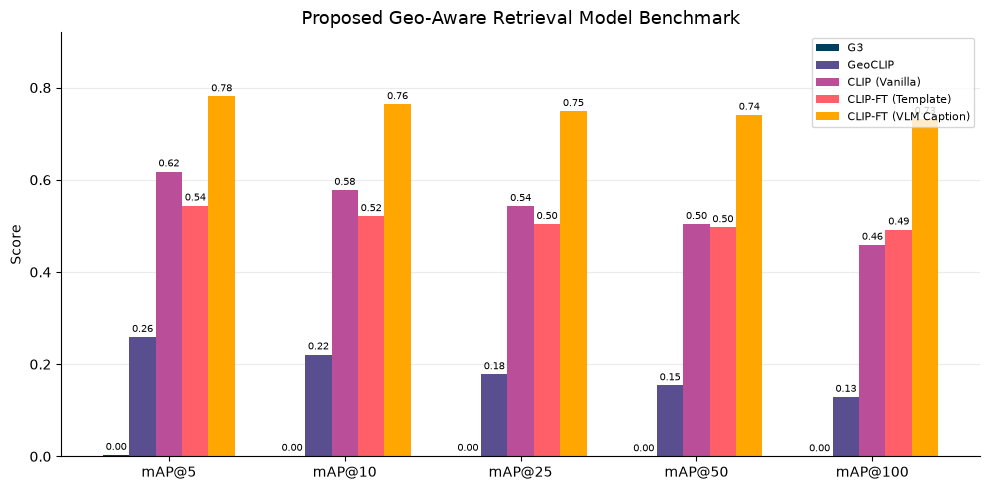

In [70]:
import matplotlib.pyplot as plt
import numpy as np
models = ["G3", "GeoCLIP", "CLIP (Vanilla)", "CLIP-FT (Template)", "CLIP-FT (VLM Caption)"]
metrics = ["mAP@5", "mAP@10", "mAP@25", "mAP@50", "mAP@100"]
data = {
"G3":                    [0.003, 0.001, 0.001, 0.000, 0.000],
"GeoCLIP":               [0.259, 0.221, 0.178, 0.154, 0.129],
"CLIP (Vanilla)":        [0.618, 0.578, 0.543, 0.504, 0.459],
"CLIP-FT (Template)":    [0.544, 0.521, 0.504, 0.497, 0.492],
"CLIP-FT (VLM Caption)": [0.781, 0.764, 0.749, 0.741, 0.732],}

colors = ["#003f5c", "#594e90", "#bb4e99", "#ff5f68", "#ffa600"]
x = np.arange(len(metrics))
n = len(models)
width = 0.15

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x + i * width, data[model], width, label=model, color=color)
    ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 0.92)
    ax.set_title("Proposed Geo-Aware Retrieval Model Benchmark", fontsize=13)
    ax.legend(loc="upper right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color="#EBEBEB")
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
# entity_df.filter(
#     (pl.col("nearby_pov_cluster").list.len() <= 0)
#     | (pl.col("nearby_pov_cluster").is_null())
# ).filter(pl.col("category") != "other").select(
#     ["entity_id", "wikimedia_url", "poi_name", "category", "poi_name_tags"]
# ).with_columns(pl.col("poi_name_tags").list.join(",")).sort("entity_id").write_csv(
#     "../dataset/csv/entities_need_more_scrap.csv"
# )

### Bridge

In [3]:
bridge_entity = entity_df.filter(pl.col("category") == "bridge")

Step 1:
- Convert splatone JSON to CSV
- Reverse geocode to obtain detailed place info

In [4]:
data = json.loads(open("../dataset/splatone/jp-bridge.json", "r").read())
bridge_df = reverse_geocode_df(to_csv(data))
bridge_df = bridge_df.filter(pl.col("country_code") == "JP")

Reverse geocoding batches: 100%|██████████| 1/1 [00:00<00:00,  1.72batch/s]


Step 2:
- Clustering and merge similar ones based on spatial and lexical

In [5]:
ner_labels = ["bridge"]
bridge_spot, bridge_cluster = run_cluster(
    bridge_df, ner_labels, similarity_threshold=0.35
)
bridge_cluster = bridge_cluster.with_columns(
    pl.col("entities").list.eval(pl.element().filter(pl.element() != ""))
)

/Users/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
NER: 100%|██████████| 5682/5682 [02:40<00:00, 35.40it/s]


In [ ]:
bridge_spot.with_columns(pl.col("entities").list.join(",")).write_csv(
    "../dataset/csv/spots/bridge_spots.csv"
)

Step 3:
- Extract relation between POI (entities) and POV (spots) (also based on spatial and lexical)

In [6]:
bridge_entity = extract_relation(
    bridge_entity, bridge_cluster, similarity_threshold=0.35
)

Step 4:
- Update entity csv (act as db lookup during retrieval)

In [ ]:
entity_df = entity_df.update(
    bridge_entity.select(["wikimedia_url", "nearby_pov_cluster"]), on="wikimedia_url"
)
entity_df.with_columns(
    [
        pl.col("poi_name_tags").list.join(","),
        pl.col("nearby_pov_cluster").cast(pl.List(pl.String)).list.join(","),
    ]
).sort("entity_id").write_csv("../dataset/csv/entities.csv")

### Palace/Castle

In [6]:
castle_entity = entity_df.filter(pl.col("category") == "palace_castle")

Step 1:
- Convert splatone JSON to CSV
- Reverse geocode to obtain detailed place info

In [8]:
data = json.loads(open("../dataset/splatone/jp-palace-castle.json", "r").read())
castle_df = reverse_geocode_df(to_csv(data))
castle_df = castle_df.filter(pl.col("country_code") == "JP")

Reverse geocoding batches: 100%|██████████| 1/1 [00:01<00:00,  1.66s/batch]


Step 2:
- Clustering and merge similar ones based on spatial and lexical

In [9]:
ner_labels = ["castle"]
castle_spot, castle_cluster = run_cluster(
    castle_df, ner_labels, similarity_threshold=0.35
)
castle_cluster = castle_cluster.with_columns(
    pl.col("entities").list.eval(pl.element().filter(pl.element() != ""))
)

/home/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
NER: 100%|██████████| 19696/19696 [13:49<00:00, 23.75it/s]


In [ ]:
castle_spot.with_columns(pl.col("entities").list.join(",")).write_csv(
    "../dataset/csv/spots/castle_spots.csv"
)

Step 3:
- Extract relation between POI (entities) and POV (spots) (also based on spatial and lexical)

In [24]:
castle_entity = extract_relation(
    castle_entity, castle_cluster, similarity_threshold=0.35
)

Step 4:
- Update entity csv (act as db lookup during retrieval)

In [ ]:
from src.preprocess.utils import plot_pov_poi

plot_pov_poi(castle_spot, castle_entity)

In [29]:
entity_df = entity_df.update(
    castle_entity.select(["wikimedia_url", "nearby_pov_cluster"]), on="wikimedia_url"
)
entity_df.with_columns(
    [
        pl.col("poi_name_tags").list.join(","),
        pl.col("nearby_pov_cluster").cast(pl.List(pl.String)).list.join(","),
    ]
).sort("entity_id").write_csv("../dataset/csv/entities.csv")

### Monument/Statue

In [11]:
monument_entity = entity_df.filter(pl.col("category") == "monument_statue")

Step 1:
- Convert splatone JSON to CSV
- Reverse geocode to obtain detailed place info

In [12]:
data = json.loads(open("../dataset/splatone/jp-monument-statue.json", "r").read())
monument_df = reverse_geocode_df(to_csv(data))
monument_df = monument_df.filter(pl.col("country_code") == "JP")

Reverse geocoding batches: 100%|██████████| 1/1 [00:00<00:00,  1.29batch/s]


Step 2:
- Clustering and merge similar ones based on spatial and lexical

In [13]:
ner_labels = ["monument", "statue"]
monument_spot, monument_cluster = run_cluster(
    monument_df, ner_labels, similarity_threshold=0.35
)
monument_cluster = monument_cluster.with_columns(
    pl.col("entities").list.eval(pl.element().filter(pl.element() != ""))
)

/home/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
NER: 100%|██████████| 3906/3906 [02:42<00:00, 23.97it/s]


In [ ]:
monument_spot.with_columns(pl.col("entities").list.join(",")).write_csv(
    "../dataset/csv/spots/monument_spots.csv"
)

Step 3:
- Extract relation between POI (entities) and POV (spots) (also based on spatial and lexical)

In [15]:
monument_entity = extract_relation(
    monument_entity, monument_cluster, similarity_threshold=0.35
)

Step 4:
- Update entity csv (act as db lookup during retrieval)

In [21]:
monument_entity.filter(pl.col("nearby_pov_cluster").list.len() <= 0)

entity_id,wikimedia_url,poi_name,wikidata_id,instance_tag,category,poi_name_tags,geohack_url,latitude,longitude,country_code,country,region,subregion,city,osm_id,nearby_pov_cluster
i64,str,str,str,str,str,list[str],str,f64,f64,str,str,str,str,str,str,list[i64]
3536,"""https://commons.wikimedia.org/…","""Hisho (Meieki)""","""Q21654298""","""[""sculpture""]""","""monument_statue""","[""飛翔"", ""hisho""]","""https://geohack.toolforge.org/…",35.171278,136.884222,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nagoya-shi""","""node/5297511939""",[]
4397,"""https://commons.wikimedia.org/…","""Turkish Memorial and Museum (K…","""Q11322055""","""[""museum"", ""monument""]""","""monument_statue""","[""トルコ記念館"", ""튀르키예 기념관"", … ""متحف ونصب كوشيموتو التذكاري التركي""]","""https://geohack.toolforge.org/…",33.469167,135.858611,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Shingu""","""node/3500177162""",[]
3461,"""https://commons.wikimedia.org/…","""Takaoka Daibutsu""","""Q11669490""","""[""statue""]""","""monument_statue""","[""高岡大仏"", ""高岡大佛"", … ""takaoka daibutsu""]","""https://geohack.toolforge.org/…",36.745639,137.017194,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Takaoka""","""node/4041250889""",[]
5280,"""https://commons.wikimedia.org/…","""Manji-no-sekibutsu""","""Q11353878""","""[""stone Buddha statue""]""","""monument_statue""","[""万治の石仏"", ""manji no sekibutsu"", … ""stone buddha of manji""]","""https://geohack.toolforge.org/…",36.082936,138.081939,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Okaya""","""node/1389203061""",[]
4432,"""https://commons.wikimedia.org/…","""Saihō-ji (Kyoto)""","""Q46123614""","""[""Buddhist temple"", ""Japanese …","""monument_statue""","[""saihouji"", ""saiho-ji""]","""https://geohack.toolforge.org/…",34.9925,135.684167,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Muko""",null,[]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6482,"""https://commons.wikimedia.org/…","""Yokozuna Stone""","""Q11543444""","""[""stele""]""","""monument_statue""","[""横綱力士碑"", ""yokozuna stone"", ""橫綱力士碑""]","""https://geohack.toolforge.org/…",35.671861,139.8,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Urayasu""",null,[]
2990,"""https://commons.wikimedia.org/…","""Port of Kobe Earthquake Memori…","""Q10855312""","""[""memorial""]""","""monument_statue""","[""고베항 지진 메모리얼 파크"", ""神戸港震災メモリアルハーク"", … ""parc memorial du tremblement de terre du port de kobe""]","""https://geohack.toolforge.org/…",34.683889,135.19,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kobe""","""way/836149534""",[]
6293,"""https://commons.wikimedia.org/…","""Ōzeki Stone""","""Q11439876""","""[""stele""]""","""monument_statue""","[""大関力士碑"", ""大關力士碑"", … ""steindenkmal fur sumo-ringer des ozeki-rangs""]","""https://geohack.toolforge.org/…",35.671028,139.799306,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Urayasu""",null,[]


In [ ]:
from src.preprocess.utils import plot_pov_poi

plot_pov_poi(monument_spot, monument_entity)
# not much correlation with POI. need further analysis

In [22]:
entity_df = entity_df.update(
    monument_entity.select(["wikimedia_url", "nearby_pov_cluster"]), on="wikimedia_url"
)
entity_df.with_columns(
    [
        pl.col("poi_name_tags").list.join(","),
        pl.col("nearby_pov_cluster").cast(pl.List(pl.String)).list.join(","),
    ]
).sort("entity_id").write_csv("../dataset/csv/entities.csv")

### Arch/Gate

In [23]:
gate_entity = entity_df.filter(pl.col("category") == "arch_gate")

Step 1:
- Convert splatone JSON to CSV
- Reverse geocode to obtain detailed place info

In [25]:
data = json.loads(open("../dataset/splatone/jp-arch-gate.json", "r").read())
gate_df = reverse_geocode_df(to_csv(data))
gate_df = gate_df.filter(pl.col("country_code") == "JP")

Reverse geocoding batches: 100%|██████████| 1/1 [00:00<00:00,  1.54batch/s]


Step 2:
- Clustering and merge similar ones based on spatial and lexical

In [ ]:
ner_labels = ["gate", "mon"]
gate_spot, gate_cluster = run_cluster(gate_df, ner_labels, similarity_threshold=0.35)
gate_cluster = gate_cluster.with_columns(
    pl.col("entities").list.eval(pl.element().filter(pl.element() != ""))
)

/home/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
NER: 100%|██████████| 7910/7910 [05:33<00:00, 23.70it/s]


In [ ]:
gate_spot.with_columns(pl.col("entities").list.join(",")).write_csv(
    "../dataset/csv/spots/gate_spots.csv"
)

Step 3:
- Extract relation between POI (entities) and POV (spots) (also based on spatial and lexical)

In [ ]:
gate_entity = extract_relation(gate_entity, gate_cluster, similarity_threshold=0.35)

Step 4:
- Update entity csv (act as db lookup during retrieval)

In [ ]:
from src.preprocess.utils import plot_pov_poi

plot_pov_poi(gate_spot, gate_entity)
# not much correlation with POI. need further analysis

In [39]:
entity_df = entity_df.update(
    gate_entity.select(["wikimedia_url", "nearby_pov_cluster"]), on="wikimedia_url"
)
entity_df.with_columns(
    [
        pl.col("poi_name_tags").list.join(","),
        pl.col("nearby_pov_cluster").cast(pl.List(pl.String)).list.join(","),
    ]
).sort("entity_id").write_csv("../dataset/csv/entities.csv")